### This notebook provides an example to generate diffusion scores for phenotype cholesterol uptake with 27 target instances.
### Customize the cell type, phenotype, target list, positive instance list, and file paths as needed.

In [5]:
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from stringdb_alias import HGNCMapper
import torch
from sklearn.model_selection import StratifiedKFold
import merge_feature as mf
import random
import os


In [6]:
def seed_everything(seed=123):
    """"
    Seed everything.
    """   
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)


In [7]:
def split_val(df):
    all_indexes = df.index.tolist()
    label_0_indexes = df[df['label'] == 0].index.tolist()
    label_1_indexes = df[df['label'] == 1].index.tolist()
    val_index = list()
    test_index = list()
    seed_everything()
    val_index.extend(random.sample(label_0_indexes,len(label_0_indexes)//10)) # 10% of the training set would be the validation set
    seed_everything()
    val_index.extend(random.sample(label_1_indexes,len(label_1_indexes)//10)) # 10% of the training set would be the validation set
    train_index = [i for i in all_indexes if i not in val_index]
    print(len(train_index),len(val_index),len(set(train_index).intersection(val_index)))
    return train_index, val_index

In [ ]:
mapper = HGNCMapper('../../Data/Graphs/9606.protein.info.v11.5.txt.gz', '../../Data/Graphs/9606.protein.aliases.v11.5.txt.gz')
graph_file = pd.read_csv('../../Data/Graphs/9606.protein.physical.links.detailed.v11.5.binary.txt',sep = ',')
physical_graph = nx.from_pandas_edgelist(graph_file, source='protein1', target='protein2')
nodes = list(physical_graph.nodes())
print(len(nodes))
celltype = 'HepG2'
non_exist_gene = pd.read_csv(f'../../Data/Raw/cellular-localization/undetected_genes_{celltype}.tsv',sep='\t')['Gene'].tolist()
pruned_gene = [mapper.get_string_ids(gene).item() for gene in non_exist_gene]
pruned_node = list(set(pruned_gene)&set(nodes))
physical_graph.remove_nodes_from(pruned_node)
isolated_nodes = list(nx.isolates(physical_graph))
print(len(isolated_nodes))
print(physical_graph.number_of_edges())
for node in isolated_nodes:
    physical_graph.add_edge(node, node)
print(physical_graph.number_of_edges())

nodes = list(physical_graph.nodes())
A_matrix = nx.to_numpy_array(physical_graph,nodes)
physical_graph.number_of_nodes()

18384
27
920893
920920


17196

In [9]:
#Calculate kernels of the physical graph
def rw_kernel(A,n_time):
    if torch.backends.mps.is_built():
        device = 'mps'
    elif torch.cuda.is_available(): 
        device = "cuda:0" 
    else:
        device = 'cpu' 
    # A is the np.array representing the adajacency matrix
    A = A/A.sum(axis=0) # this step is equal to A*inv(D)
    A = torch.tensor(A)
    A = A.float()
    A = A.to(device)
    return torch.linalg.matrix_power(A, n_time).detach().cpu().numpy()

In [10]:
def rwr_kernel(A,rst_rate):
    if torch.backends.mps.is_built():
        device = 'mps'
    elif torch.cuda.is_available(): 
        device = "cuda:0" 
    else:
        device = 'cpu' 
    # calculate the matrix
    if rst_rate != 0.:
        Dinv = np.diag(1 / A.sum(axis=0))
        Dinv = torch.tensor(Dinv,dtype=torch.float32)
        Dinv = Dinv.to(device)
        A = torch.tensor(A,dtype=torch.float32)
        A = A.to(device)
        W = A @ Dinv
        A = A.detach().cpu().numpy()
        W = W.detach().cpu().numpy()
        I = np.eye(A.shape[0])
        Inv_W = np.linalg.inv((I - (1 - rst_rate) * W))
        # Convert to torch.tensor
        Inv_W = torch.tensor(Inv_W)
        result = rst_rate * Inv_W
        return result.detach().cpu().numpy()
    else:
        W = np.tile(A.sum(axis=1, keepdims=True) / A.sum(), [1, A.shape[0]])
        return W

In [11]:
def heat_kernel(A,alpha):
    if torch.backends.mps.is_built():
        device = 'mps'
    elif torch.cuda.is_available(): 
        device = "cuda:0" 
    else:
        device = 'cpu' 
    # alpha is the smoothing parameter
    D = np.diag(A.sum(axis=0))
    W = D - A
    W = torch.tensor(W,dtype=torch.float32)
    #W = W.to(device)
    return torch.matrix_exp(-1 * alpha * W).detach().cpu().numpy()


In [12]:
phenotype = 'LDLR'

In [ ]:
spl_data = pd.read_csv('../../Data/Datasets/'+phenotype+'/shortest_path_length_data_target27.csv',index_col=0)
# pos = spl_data[spl_data['label']==1].index.tolist()
pos = list(np.load('../../Data/Raw/'+phenotype+'/'+phenotype+'_pos_gene.npy'))
len(pos)
# np.save('../Data/Raw/'+phenotype+'/'+phenotype+'_pos_gene.npy', pos)

473

17741
label
0.0    17272
1.0      469
Name: count, dtype: int64
0.6311855539018991
[0.         0.01001621 0.53560676 0.92392311 0.93168133 0.93173923
 1.        ] [0.         0.01279318 0.79104478 0.98294243 0.98507463 0.98507463
 1.        ]


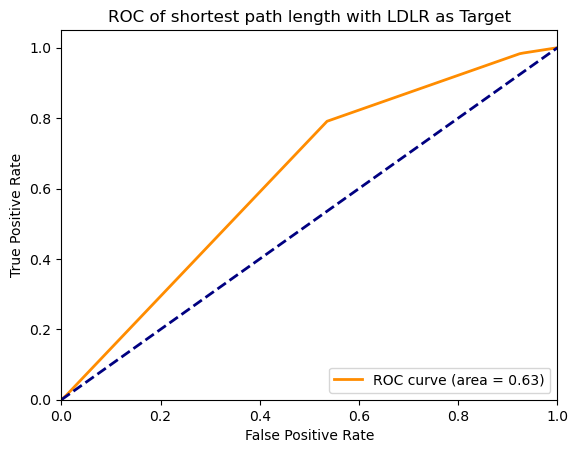

In [ ]:
all_ins = list()
spl_data = pd.read_csv('../../Data/Datasets/'+phenotype+'/shortest_path_length_data.csv',index_col=0)
spl_pos = list(set(np.load('../../Data/Raw/'+phenotype+'/'+phenotype+'_pos_gene.npy')).intersection(set(spl_data.index.tolist())))
spl_data.loc[spl_pos,'label'] = 1
target = list(np.load('../../Data/Raw/targets/'+phenotype+'_target_27.npy'))
spl_data = spl_data.drop(target)
print(len(spl_data))
print(spl_data['label'].value_counts())
scores = spl_data['shortest_path_length'].to_list()
labels = spl_data['label'].to_list()
# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)
print(roc_auc)
print(fpr,tpr)
# roc_auc
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC of shortest path length with LDLR as Target')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()
        

In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=123)
print(len(spl_data))
train_fold = list()
val_fold = list()
test_fold = list()
X = spl_data.iloc[:,:-1]
y = spl_data.iloc[:,-1]
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
        all_train_data = spl_data.iloc[train_index,:]
        train_index,val_index = split_val(all_train_data)
        train_data = spl_data.loc[train_index,:]
        val_data = spl_data.loc[val_index,:]
        test_data = spl_data.iloc[test_index,:]
        train_fold.append(train_data.index.tolist())
        val_fold.append(val_data.index.tolist())
        test_fold.append(test_data.index.tolist())
label_data = spl_data['label']
all_pos = spl_data[spl_data['label']==1].index.tolist()
all_instances = spl_data.index.tolist()

17767
12793 1420 0
12793 1420 0
12794 1420 0
12794 1420 0
12794 1420 0


All Scores

In [34]:
len(all_instances)

17741

In [ ]:
k_steps = [10,20,30]
ratio_list = list()
all_instances = spl_data.index.tolist()
# target = [mapper.get_string_ids('LDLR').item()]
target = list(np.load('../../Data/Raw/targets/'+phenotype+'_target_27.npy'))
start_node = np.array([1 if node in target else 0 for node in nodes])
S1 = rw_kernel(A_matrix,10)
S2 = rw_kernel(A_matrix,20)
S3 = rw_kernel(A_matrix,30)
p1 = S1@start_node
p2 = S2@start_node
p3 = S3@start_node
rank = pd.DataFrame({'protein':nodes,'RW_target_10':p1,'RW_target_20':p2,'RW_target_30':p3})
rank = rank[['protein','RW_target_10','RW_target_20','RW_target_30']]
rank = rank.set_index('protein')
rank.to_csv('../../Data/Datasets/'+phenotype+'/RW_target_27.csv')

In [ ]:
k_steps = [10,20,30]
ratio_list = list()
# target = mapper.get_string_ids('LDLR').item()
target = list(np.load('../../Data/Raw/targets/'+phenotype+'_target_27.npy'))
for i in k_steps:
    S = rw_kernel(A_matrix,i)
    rank = pd.DataFrame({'protein':nodes})
    rank = mf.add_mask(rank,all_instances)
    rank = rank[rank['train_mask']==True]
    rank = rank['protein']
    rw_score = rank
    for r in range(1,11):
        ratio = r/10
        ratio_list.append(ratio)
        rw_score_ratio = pd.DataFrame()
        for j in range(5):
            train_set_protein = train_fold[j]
            test_instances = test_fold[j]
            sampled_train_node = pd.DataFrame(np.array(train_set_protein),columns=['protein']).sample(frac=ratio, random_state=123)['protein'].tolist()
            sampled_start_node = list(set(all_pos).intersection(set(sampled_train_node)))
            for targets in target:
                sampled_start_node.append(targets)
            # sampled_start_node.append(target)
            start_node = np.array([1 if node in sampled_start_node else 0 for node in nodes])
            p = S@start_node
            rank = pd.DataFrame({'protein':nodes,'RW_'+str(i)+'_'+str(ratio):p})
            rank = mf.add_mask(rank,test_instances)
            rank = rank[rank['train_mask']==True]
            rank = rank[['protein','RW_'+str(i)+'_'+str(ratio)]]
            # print(rank)
            rw_score_ratio =pd.concat([rw_score_ratio,rank])
        rw_score = pd.merge(rw_score,rw_score_ratio,how='outer')
    rw_score.set_index('protein',inplace = True)
    
    rw_score.to_csv('../../Data/Datasets/'+phenotype+'/RW_'+str(i)+'_target_27.csv')
        

In [ ]:
restart_state = [0.2,0.4,0.6]
ratio_list = list()
# target = [mapper.get_string_ids('LDLR').item()]
target = list(np.load('../../Data/Raw/targets/'+phenotype+'_target_27.npy'))
start_node = np.array([1 if node in target else 0 for node in nodes])
# all_instances = spl_data.index.tolist()
S1 = rwr_kernel(A_matrix,0.2)
S2 = rwr_kernel(A_matrix,0.4)
S3 = rwr_kernel(A_matrix,0.6)
p1 = S1@start_node
p2 = S2@start_node
p3 = S3@start_node
rank = pd.DataFrame({'protein':nodes,'RWR_target_0.2':p1,'RWR_target_0.4':p2,'RWR_target_0.6':p3})
rank = rank[['protein','RWR_target_0.2','RWR_target_0.4','RWR_target_0.6']]
rank = rank.set_index('protein')
rank.to_csv('../../Data/Datasets/'+phenotype+'/RWR_target_27.csv')

In [ ]:
restart_state = [0.2,0.4,0.6]
ratio_list = list()
# target = mapper.get_string_ids('LDLR').item()
target = list(np.load('../../Data/Raw/targets/'+phenotype+'_target_27.npy'))
for i in restart_state:
    S = rwr_kernel(A_matrix,i)
    rank = pd.DataFrame({'protein':nodes})
    rank = mf.add_mask(rank,all_instances)
    rank = rank[rank['train_mask']==True]
    rank = rank[['protein']]
    rwr_score = rank
    for r in range(1,11):
        ratio = r/10
        ratio_list.append(ratio)
        rwr_score_ratio = pd.DataFrame()
        for j in range(5):
            train_set_protein = train_fold[j]
            test_instances = test_fold[j]
            sampled_train_node = pd.DataFrame(np.array(train_set_protein),columns=['protein']).sample(frac=ratio, random_state=123)['protein'].tolist()
            sampled_start_node = list(set(all_pos).intersection(set(sampled_train_node)))
            for targets in target:
                sampled_start_node.append(targets)
            #sampled_start_node.append(target)
            start_node = np.array([1 if node in sampled_start_node else 0 for node in nodes])
            p = S@start_node
            rank = pd.DataFrame({'protein':nodes,'RWR_'+str(i)+'_'+str(ratio):p})
            rank = mf.add_mask(rank,test_instances)
            rank = rank[rank['train_mask']==True]
            rank = rank[['protein','RWR_'+str(i)+'_'+str(ratio)]]
            rwr_score_ratio = pd.concat([rwr_score_ratio,rank])
        rwr_score = pd.merge(rwr_score,rwr_score_ratio,how='outer')
    rwr_score.set_index('protein',inplace = True)
    rwr_score.to_csv('../../Data/Datasets/'+phenotype+'/RWR_'+str(i)+'_target_27.csv')
        

In [ ]:
alpha_list = [0.1,0.2,0.3]
ratio_list = list()
# target = [mapper.get_string_ids('LDLR').item()]
target = list(np.load('../../Data/Raw/targets/'+phenotype+'_target_27.npy'))
start_node = np.array([1 if node in target else 0 for node in nodes])
S1 = heat_kernel(A_matrix,0.1)
S2 = heat_kernel(A_matrix,0.2)
S3 = heat_kernel(A_matrix,0.3)
p1 = S1@start_node
p2 = S2@start_node
p3 = S3@start_node
rank = pd.DataFrame({'protein':nodes,'Heat_target_0.1':p1,'Heat_target_0.2':p2,'Heat_target_0.3':p3})
rank = rank[['protein','Heat_target_0.1','Heat_target_0.2','Heat_target_0.3']]
rank = rank.set_index('protein')
rank.to_csv('../../Data/Datasets/'+phenotype+'/Heat_target_27.csv')

In [ ]:
alpha_list = [0.1,0.2,0.3]
ratio_list = list()
# target = mapper.get_string_ids('LDLR').item()
target = list(np.load('../../Data/Raw/targets/'+phenotype+'_target_27.npy'))
for i in alpha_list:
    S = heat_kernel(A_matrix,i)
    rank = pd.DataFrame({'protein':nodes})
    rank = mf.add_mask(rank,all_instances)
    rank = rank[rank['train_mask']==True]
    rank = rank[['protein']]
    heat_score = rank
    for r in range(1,11):
        ratio = r/10
        ratio_list.append(ratio)
        heat_score_ratio = pd.DataFrame()
        for j in range(5):
            train_set_protein = train_fold[j]
            test_instances = test_fold[j]
            sampled_train_node = pd.DataFrame(np.array(train_set_protein),columns=['protein']).sample(frac=ratio, random_state=123)['protein'].tolist()
            sampled_start_node = list(set(all_pos).intersection(set(sampled_train_node)))
            for targets in target:
                sampled_start_node.append(targets)
            #sampled_start_node.append(target)
            start_node = np.array([1 if node in sampled_start_node else 0 for node in nodes])
            p = S@start_node
            rank = pd.DataFrame({'protein':nodes,'heat_'+str(i)+'_'+str(ratio):p})
            rank = mf.add_mask(rank,test_instances)
            rank = rank[rank['train_mask']==True]
            rank = rank[['protein','heat_'+str(i)+'_'+str(ratio)]]
            heat_score_ratio = pd.concat([heat_score_ratio,rank])
        heat_score = pd.merge(heat_score,heat_score_ratio,how='outer')
    heat_score.set_index('protein',inplace = True)
    heat_score.to_csv('../../Data/Datasets/'+phenotype+'/heat_'+str(i)+'_target_27.csv')


In [ ]:
for i in k_steps:
    diffusion_score = pd.read_csv('../../Data/Datasets/'+phenotype+'/RW_'+str(i)+'_target_27.csv',index_col=0)
    diffusion_score = pd.merge(spl_data,diffusion_score,left_index=True,right_index=True,how='left')
    diffusion_score.fillna(0,inplace=True)
    diffusion_score = mf.move2last(diffusion_score,'label')
    diffusion_score = diffusion_score.drop(['shortest_path_length','label'],axis=1)
    diffusion_score.to_csv('../../Data/Datasets/'+phenotype+'/RW_'+str(i)+'_target_27.csv')

In [ ]:
for i in restart_state:
    diffusion_score = pd.read_csv('../../Data/Datasets/'+phenotype+'/RWR_'+str(i)+'_target_27.csv',index_col=0)
    diffusion_score = pd.merge(spl_data,diffusion_score,left_index=True,right_index=True,how='left')
    diffusion_score.fillna(0,inplace=True)
    diffusion_score = mf.move2last(diffusion_score,'label')
    diffusion_score = diffusion_score.drop(['shortest_path_length','label'],axis=1)
    diffusion_score.to_csv('../../Data/Datasets/'+phenotype+'/RWR_'+str(i)+'_target_27.csv')

In [ ]:
for i in alpha_list:
    diffusion_score = pd.read_csv('../../Data/Datasets/'+phenotype+'/heat_'+str(i)+'_target_27.csv',index_col=0)
    diffusion_score = pd.merge(spl_data,diffusion_score,left_index=True,right_index=True,how='left')
    diffusion_score.fillna(0,inplace=True)
    diffusion_score = mf.move2last(diffusion_score,'label')
    diffusion_score = diffusion_score.drop(['shortest_path_length','label'],axis=1)
    print(diffusion_score)
    diffusion_score.to_csv('../../Data/Datasets/'+phenotype+'/heat_'+str(i)+'_target_27.csv')

                      heat_0.1_0.1  heat_0.1_0.2  heat_0.1_0.3  heat_0.1_0.4  \
protein                                                                        
9606.ENSP00000391488      0.001414      0.001999      0.003042      0.003896   
9606.ENSP00000361748      0.000351      0.000544      0.000803      0.000940   
9606.ENSP00000356641      0.004029      0.006033      0.008939      0.010631   
9606.ENSP00000417581      0.002139      0.003700      0.005100      0.007629   
9606.ENSP00000365006      0.004846      0.006746      0.008735      0.010139   
...                            ...           ...           ...           ...   
9606.ENSP00000356694      0.000000      0.000000      0.000000      0.000000   
9606.ENSP00000340610      0.003391      0.005951      0.008574      0.010443   
9606.ENSP00000370867      0.000000      0.000000      0.000000      0.000000   
9606.ENSP00000354223      0.003856      0.006099      0.009345      0.011712   
9606.ENSP00000438085      0.004017      

In [ ]:
spl_data = pd.read_csv('../../Data/Datasets/'+phenotype+'/shortest_path_length_data_target27.csv',index_col=0)

for i in ['RW','RWR','heat']:
    diffusion_score = pd.read_csv('../../Data/Datasets/'+phenotype+'/'+i+'_target_6.csv',index_col=0)
    diffusion_score = pd.merge(spl_data,diffusion_score,left_index=True,right_index=True, how = 'left')
    diffusion_score = diffusion_score.fillna(0)
    diffusion_score = diffusion_score.drop(['shortest_path_length','label'],axis=1)
    print(diffusion_score)
    diffusion_score.to_csv('../../Data/Datasets/'+phenotype+'/'+i+'_target_27.csv')

                      RW_target_10  RW_target_20  RW_target_30
protein                                                       
9606.ENSP00000391488      0.000021      0.000020      0.000020
9606.ENSP00000361748      0.000004      0.000003      0.000003
9606.ENSP00000356641      0.001139      0.001181      0.001182
9606.ENSP00000417581      0.000086      0.000078      0.000078
9606.ENSP00000365006      0.000089      0.000079      0.000078
...                            ...           ...           ...
9606.ENSP00000356694      0.000000      0.000000      0.000000
9606.ENSP00000340610      0.001637      0.001650      0.001648
9606.ENSP00000370867      0.000000      0.000000      0.000000
9606.ENSP00000354223      0.000147      0.000147      0.000147
9606.ENSP00000438085      0.000449      0.000421      0.000420

[17768 rows x 3 columns]
                      RWR_target_0.2  RWR_target_0.4  RWR_target_0.6
protein                                                             
9606.ENSP00000391

Add diffusion scores as additional set of features


In [ ]:
train_data = pd.read_csv('../../Data/Datasets/LDLR/train_node_attribute_LDLR_with_target_feature_no_diffuse_target_27.csv',index_col=0)
diffusion_score = pd.read_csv('../../Data/Datasets/LDLR/RWR_target_27.csv')
train_data = pd.merge(train_data,diffusion_score,how='left',left_on = 'protein',right_on='protein')
train_data = mf.move2last(train_data,'label')
train_data = train_data.set_index('protein')
train_data
train_data.to_csv('../../Data/Datasets/LDLR/train_node_attribute_LDLR_with_target_feature_target_27.csv')